# 1. Data Cleaning and Auditing

The Formula 1 dataset consists of 14 relational CSV tables. Before constructing the
modeling dataset, the raw data is explored and audited to identify missing values,
incorrect data types, duplicate records, and relational-integrity problems.

The cleaning process includes:
- exploratory data analysis before cleaning;
- detection and cleaning of `\N` sentinel values;
- semantic typing of dates and durations;
- primary-key and foreign-key validation;
- investigation and resolution of duplicate `(raceId, driverId)` records;
- and exploratory analysis after cleaning.

The original DataFrames are preserved unchanged. All cleaning operations are
performed on separate copies.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

In [7]:
DATA_PATH = "/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020"

file_names = [
    "circuits",
    "constructors",
    "constructor_results",
    "constructor_standings",
    "drivers",
    "driver_standings",
    "races",
    "results",
    "qualifying",
    "lap_times",
    "pit_stops",
    "sprint_results",
    "seasons",
    "status"
]

raw_data = {}

for name in file_names:
    raw_data[name] = pd.read_csv(
        f"{DATA_PATH}/{name}.csv"
    )

print("Number of tables loaded:", len(raw_data))

Number of tables loaded: 14


## 1.1 Initial Exploratory Data Analysis

The raw tables are first explored without modification. Their dimensions, data types,
summary statistics, missing values, duplicate rows, and placeholder values are
examined programmatically.

This provides a baseline for identifying cleaning requirements and allows the effect
of cleaning to be evaluated later.

In [8]:
for name, df in raw_data.items():
    print(f"\n{name.upper()}")
    display(df.head())


CIRCUITS


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park



CONSTRUCTORS


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso



CONSTRUCTOR_RESULTS


...

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1
3,4,1061,844,6,16,4,4,4,4,0,17,+11.278,1549704,16,1:30.163,1
4,5,1061,846,1,4,6,5,5,5,0,17,+24.111,1562537,16,1:30.566,1



SEASONS


,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...
3,2006,http://en.wikipedia.org/wiki/2006_Formula_One_...
4,2005,http://en.wikipedia.org/wiki/2005_Formula_One_...



STATUS


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [9]:
overview = []

for name, df in raw_data.items():
    overview.append({
        "Table": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

overview_df = pd.DataFrame(overview)

display(overview_df)

,Table,Rows,Columns
0,circuits,77,9
1,constructors,212,5
2,constructor_results,12625,5
3,constructor_standings,13391,7
4,drivers,861,9
5,driver_standings,34863,7
6,races,1125,18
7,results,26759,18
8,qualifying,10494,9
9,lap_times,589081,6


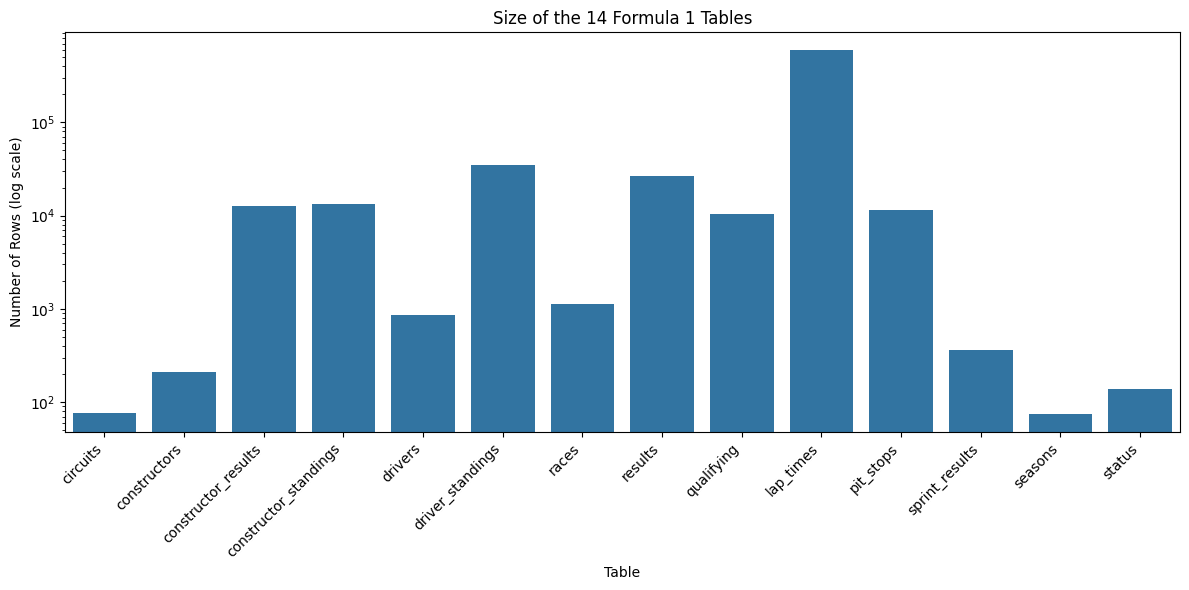

In [10]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=overview_df,
    x="Table",
    y="Rows"
)

plt.yscale("log")
plt.title("Size of the 14 Formula 1 Tables")
plt.xlabel("Table")
plt.ylabel("Number of Rows (log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [83]:
for name, df in raw_data.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    df.info()


CIRCUITS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   77 non-null     int64  
 1   circuitRef  77 non-null     object 
 2   name        77 non-null     object 
 3   location    77 non-null     object 
 4   country     77 non-null     object 
 5   lat         77 non-null     float64
 6   lng         77 non-null     float64
 7   alt         77 non-null     int64  
 8   url         77 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.5+ KB

CONSTRUCTORS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   212 non-null    int64 
 1   constructorRef  212 non-null    object
 2   name            212 non-null    object
 3   nationality     212 non-null    

In [11]:
for name, df in raw_data.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    display(df.describe())


CIRCUITS


,circuitId,lat,lng,alt
count,77.000000,77.000000,77.000000,77.000000
mean,39.883117,33.442925,1.076683,247.012987
std,23.001701,22.808866,65.516951,362.738469
min,1.000000,-37.849700,-118.189000,-7.000000
25%,20.000000,32.777400,-9.394170,18.000000
50%,40.000000,40.951700,3.930830,129.000000
75%,59.000000,46.958900,19.248600,332.000000
max,80.000000,57.265300,144.968000,2227.000000



CONSTRUCTORS


,constructorId
count,212.000000
mean,107.547170
std,61.952685
min,1.000000
25%,54.750000
50%,107.500000
75%,160.250000
max,215.000000



CONSTRUCTOR_RESULTS


...

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,statusId
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,180.500000,1106.944444,734.658333,94.366667,28.177778,9.922222,10.500000,1.550000,19.583333,3.336111
std,104.067286,25.636134,276.412115,89.166421,23.796293,5.842363,5.774307,2.496293,4.752803,13.447963
min,1.000000,1061.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,90.750000,1084.000000,822.000000,6.000000,11.000000,5.000000,5.750000,0.000000,18.000000,1.000000
50%,180.500000,1112.500000,840.000000,84.000000,22.000000,10.000000,10.500000,0.000000,19.000000,1.000000
75%,270.250000,1126.000000,848.000000,210.000000,44.000000,15.000000,15.250000,3.000000,24.000000,1.000000
max,360.000000,1143.000000,861.000000,215.000000,99.000000,20.000000,20.000000,8.000000,24.000000,130.000000



SEASONS


,year
count,75.000000
mean,1987.000000
std,21.794495
min,1950.000000
25%,1968.500000
50%,1987.000000
75%,2005.500000
max,2024.000000



STATUS


,statusId
count,139.000000
mean,71.237410
std,41.092434
min,1.000000
25%,35.500000
50%,72.000000
75%,106.500000
max,141.000000


### Initial Data Observations

The initial inspection shows that the 14 tables vary substantially in size, with
`lap_times` being the largest table.

Several fields also require semantic type conversion. Date variables such as
`races.date` and `drivers.dob` are currently stored as `object`, while duration
variables such as qualifying lap times and pit-stop durations are also stored as text.

The numerical summaries show large ranges in some duration-related variables,
particularly lap times and pit-stop durations. These values are noted for further
inspection rather than treated as errors at this stage.

The next steps examine duplicate records and missing values before any cleaning is
applied.

In [85]:
duplicate_summary = []

for name, df in raw_data.items():
    duplicate_summary.append({
        "Table": name,
        "Exact_Duplicate_Rows": df.duplicated().sum()
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

display(duplicate_summary)

,Table,Exact_Duplicate_Rows
0,circuits,0
1,constructors,0
2,constructor_results,0
3,constructor_standings,0
4,drivers,0
5,driver_standings,0
6,races,0
7,results,0
8,qualifying,0
9,lap_times,0


## 1.2 Sentinel and Missing-Value Analysis

The Formula 1 CSV files use the literal string `\N` as a sentinel representing
missing or unavailable information.

Because `\N` is a text placeholder rather than a proper missing value, its frequency
is measured before cleaning. Both the number and percentage of sentinel values are
calculated for each affected column and visualized before any replacement is made.

In [86]:
sentinel_summary = []

for table_name, df in raw_data.items():
    for column in df.columns:

        count = (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

        if count > 0:
            sentinel_summary.append({
                "Table": table_name,
                "Column": column,
                "Count": count,
                "Percentage": count / len(df) * 100
            })

sentinel_summary = pd.DataFrame(sentinel_summary)

sentinel_summary = sentinel_summary.sort_values(
    "Percentage",
    ascending=False
).reset_index(drop=True)

display(sentinel_summary)

,Table,Column,Count,Percentage
0,constructor_results,status,12608,99.865347
1,races,sprint_time,1110,98.666667
2,races,sprint_date,1107,98.400000
3,races,fp3_time,1072,95.288889
4,races,fp2_time,1057,93.955556
5,races,fp1_time,1057,93.955556
6,races,quali_time,1057,93.955556
7,races,fp3_date,1053,93.600000
8,drivers,number,802,93.147503
9,races,fp1_date,1035,92.000000


### Total Missingness Before Cleaning

The previous analysis counts only the literal `\N` sentinel values. Some columns also
contain values that Pandas already recognizes as missing (`NaN`).

Therefore, total missingness is calculated using both existing null values and `\N`
sentinels to obtain the complete missing-data picture before cleaning.

In [88]:
missing_before = []

for table_name, df in raw_data.items():
    for column in df.columns:

        null_count = df[column].isnull().sum()

        sentinel_count = (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

        total_missing = null_count + sentinel_count

        if total_missing > 0:
            missing_before.append({
                "Table": table_name,
                "Column": column,
                "Missing_Count": total_missing,
                "Missing_Percentage": total_missing / len(df) * 100
            })

missing_before = pd.DataFrame(missing_before)

missing_before = missing_before.sort_values(
    "Missing_Percentage",
    ascending=False
).reset_index(drop=True)

display(missing_before.head(30))

,Table,Column,Missing_Count,Missing_Percentage
0,constructor_results,status,12608,99.865347
1,races,sprint_time,1110,98.666667
2,races,sprint_date,1107,98.400000
3,races,fp3_time,1072,95.288889
4,races,fp2_time,1057,93.955556
5,races,fp1_time,1057,93.955556
6,races,quali_time,1057,93.955556
7,races,fp3_date,1053,93.600000
8,drivers,number,802,93.147503
9,races,fp1_date,1035,92.000000


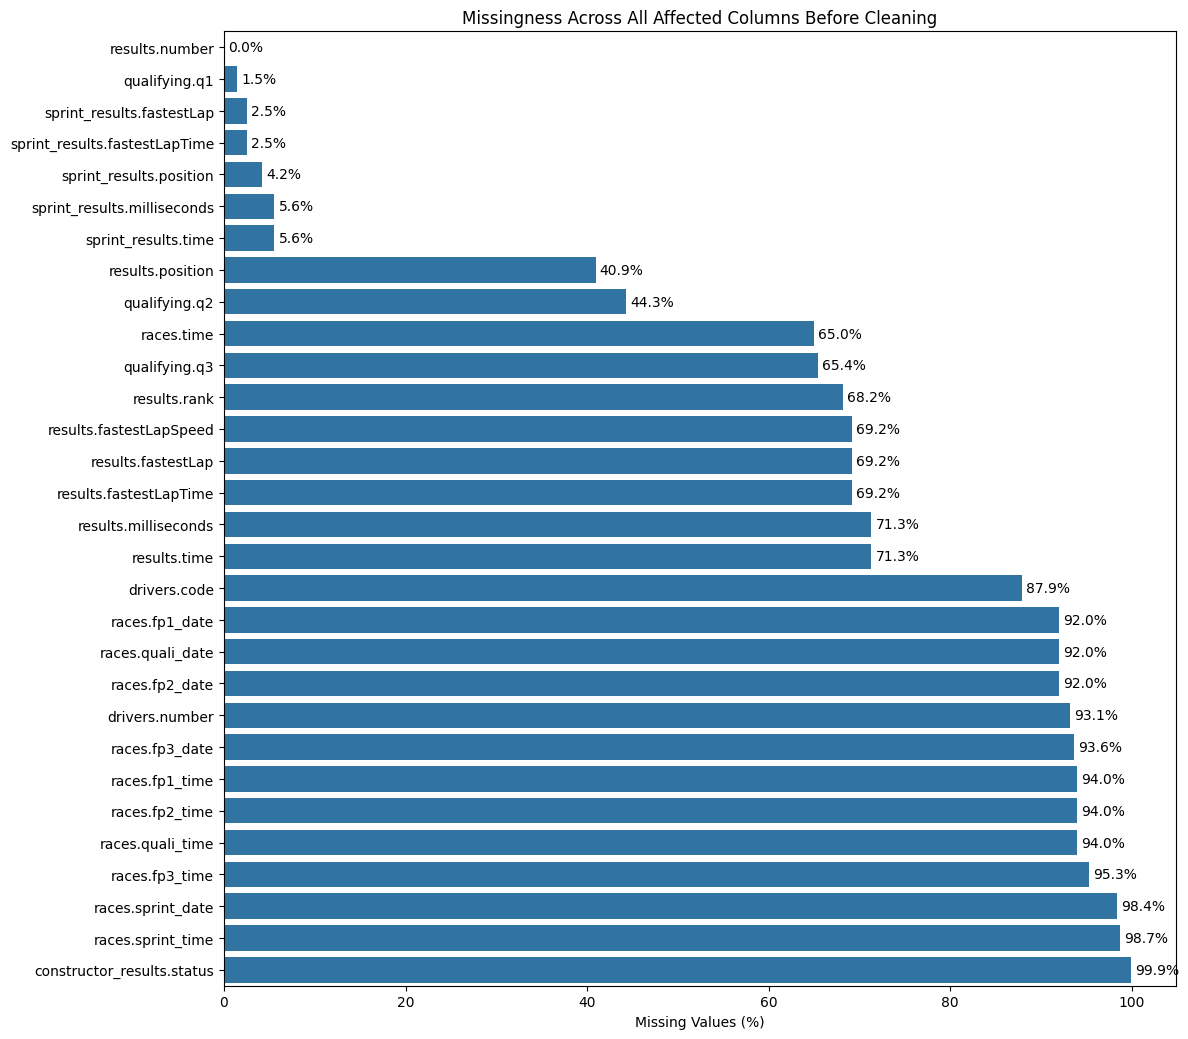

In [130]:
missing_before_plot = (
    missing_before
    .sort_values(
        "Missing_Percentage",
        ascending=True
    )
    .copy()
)

missing_before_plot["Feature"] = (
    missing_before_plot["Table"]
    + "."
    + missing_before_plot["Column"]
)

plt.figure(
    figsize=(
        12,
        max(6, len(missing_before_plot) * 0.35)
    )
)

ax = sns.barplot(
    data=missing_before_plot,
    x="Missing_Percentage",
    y="Feature"
)

plt.title("Missingness Across All Affected Columns Before Cleaning")
plt.xlabel("Missing Values (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

## 1.3 Cleaning Copies

The original tables stored in `raw_data` are preserved without modification.
Independent copies are created in `clean_data`, and all subsequent transformations
are applied only to these copies.

This allows the original source data to remain available for auditing and for direct
before-versus-after comparisons.

In [22]:
clean_data = {
    name: df.copy()
    for name, df in raw_data.items()
}

print("Cleaning copies created:", len(clean_data))

Cleaning copies created: 14


## 1.4 Cleaning Sentinel Values

All `\N` sentinel values are converted to `NaN`, Pandas' standard representation of
missing data.

Since the final objective is to predict whether a driver finishes on the podium, not
every column in the 14 source tables will be used as a predictive feature. Therefore,
missing values are not dropped or imputed at this stage. Instead, they are represented
correctly as `NaN`, and their treatment will be determined later for the features
selected for the final modeling table.

In [23]:
for name in clean_data:
    clean_data[name] = clean_data[name].replace(
        r"^\s*\\N\s*$",
        np.nan,
        regex=True
    )

print("Sentinel replacement complete.")

Sentinel replacement complete.


In [24]:
remaining_sentinels = 0

for name, df in clean_data.items():
    for column in df.columns:

        remaining_sentinels += (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

print("Remaining \\N sentinel values:", remaining_sentinels)

Remaining \N sentinel values: 0


## 1.5 Semantic Data Types

Several fields are stored as strings even though they represent dates or durations.

Race-event dates and driver dates of birth are converted to datetime values. Genuine
duration fields, such as qualifying lap times, fastest-lap times, lap times, and pit-stop
durations, are converted to numeric seconds.

The original duration columns are retained while new `_seconds` columns are created,
preserving the original representation for auditing.

`results.time` and `sprint_results.time` are not converted using the generic duration
function because these columns mix full elapsed race times with time gaps such as
`+5.478`, which do not have the same semantic meaning.

In [25]:
race_date_columns = [
    "date",
    "fp1_date",
    "fp2_date",
    "fp3_date",
    "quali_date",
    "sprint_date"
]

for column in race_date_columns:
    clean_data["races"][column] = pd.to_datetime(
        clean_data["races"][column],
        errors="coerce"
    )

clean_data["drivers"]["dob"] = pd.to_datetime(
    clean_data["drivers"]["dob"],
    errors="coerce"
)

print("Date conversion complete.")

Date conversion complete.


In [26]:
numeric_columns = {
    "results": [
        "position",
        "milliseconds",
        "fastestLap",
        "rank",
        "fastestLapSpeed"
    ],
    "sprint_results": [
        "position",
        "milliseconds",
        "fastestLap"
    ]
}

for table_name, columns in numeric_columns.items():
    for column in columns:
        clean_data[table_name][column] = pd.to_numeric(
            clean_data[table_name][column],
            errors="coerce"
        )

print("Numeric semantic typing complete.")

Numeric semantic typing complete.


In [32]:
def time_to_seconds(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "":
        return np.nan

    parts = value.split(":")

    try:
        if len(parts) == 1:
            return float(parts[0])

        elif len(parts) == 2:
            minutes = float(parts[0])
            seconds = float(parts[1])

            return minutes * 60 + seconds

        elif len(parts) == 3:
            hours = float(parts[0])
            minutes = float(parts[1])
            seconds = float(parts[2])

            return (
                hours * 3600
                + minutes * 60
                + seconds
            )

    except ValueError:
        return np.nan

    return np.nan

In [34]:
duration_columns = {
    "results": [
        "fastestLapTime"
    ],

    "qualifying": [
        "q1",
        "q2",
        "q3"
    ],

    "lap_times": [
        "time"
    ],

    "pit_stops": [
        "duration"
    ],

    "sprint_results": [
        "fastestLapTime"
    ]
}

In [35]:
for table_name, columns in duration_columns.items():

    for column in columns:

        clean_data[table_name][
            f"{column}_seconds"
        ] = (
            clean_data[table_name][column]
            .apply(time_to_seconds)
        )

print("Duration conversion complete.")

Duration conversion complete.


In [36]:
print("DATE TYPES")
print("-" * 40)

print(
    clean_data["races"][
        race_date_columns
    ].dtypes
)

print(
    "\ndrivers.dob =",
    clean_data["drivers"]["dob"].dtype
)

DATE TYPES
----------------------------------------
date           datetime64[ns]
fp1_date       datetime64[ns]
fp2_date       datetime64[ns]
fp3_date       datetime64[ns]
quali_date     datetime64[ns]
sprint_date    datetime64[ns]
dtype: object

drivers.dob = datetime64[ns]


In [37]:
print("NUMERIC TYPES")
print("-" * 40)

for table_name, columns in numeric_columns.items():

    print(f"\n{table_name.upper()}")

    for column in columns:
        print(
            f"{column}:",
            clean_data[table_name][column].dtype
        )

NUMERIC TYPES
----------------------------------------

RESULTS
position: float64
milliseconds: float64
fastestLap: float64
rank: float64
fastestLapSpeed: float64

SPRINT_RESULTS
position: float64
milliseconds: float64
fastestLap: float64


In [38]:
print("DURATION TYPES")
print("-" * 40)

duration_check_columns = {
    "results": [
        "fastestLapTime_seconds"
    ],

    "qualifying": [
        "q1_seconds",
        "q2_seconds",
        "q3_seconds"
    ],

    "lap_times": [
        "time_seconds"
    ],

    "pit_stops": [
        "duration_seconds"
    ],

    "sprint_results": [
        "fastestLapTime_seconds"
    ]
}

for table_name, columns in duration_check_columns.items():

    for column in columns:

        print(
            f"{table_name}.{column} =",
            clean_data[table_name][column].dtype
        )

DURATION TYPES
----------------------------------------
results.fastestLapTime_seconds = float64
qualifying.q1_seconds = float64
qualifying.q2_seconds = float64
qualifying.q3_seconds = float64
lap_times.time_seconds = float64
pit_stops.duration_seconds = float64
sprint_results.fastestLapTime_seconds = float64


In [39]:
display(
    clean_data["qualifying"][
        [
            "q1",
            "q1_seconds",
            "q2",
            "q2_seconds",
            "q3",
            "q3_seconds"
        ]
    ].head(10)
)

,q1,q1_seconds,q2,q2_seconds,q3,q3_seconds
0,1:26.572,86.572,1:25.187,85.187,1:26.714,86.714
1,1:26.103,86.103,1:25.315,85.315,1:26.869,86.869
2,1:25.664,85.664,1:25.452,85.452,1:27.079,87.079
3,1:25.994,85.994,1:25.691,85.691,1:27.178,87.178
4,1:25.960,85.960,1:25.518,85.518,1:27.236,87.236
5,1:26.427,86.427,1:26.101,86.101,1:28.527,88.527
6,1:26.295,86.295,1:26.059,86.059,1:28.687,88.687
7,1:26.381,86.381,1:26.063,86.063,1:29.041,89.041
8,1:26.919,86.919,1:26.164,86.164,1:29.593,89.593
9,1:26.702,86.702,1:25.842,85.842,NaN,NaN


### Semantic-Typing Observations

The semantic-typing step ensures that variables are represented according to their
actual meaning rather than simply retaining the data types assigned when the CSV files
were loaded.

Race-event dates (`date`, `fp1_date`, `fp2_date`, `fp3_date`, `quali_date`, and
`sprint_date`) and driver dates of birth (`dob`) were converted from text to datetime
values. This allows them to be treated as genuine dates in later analysis rather than
categorical strings.

Result variables such as `position`, `milliseconds`, `fastestLap`, `rank`, and
`fastestLapSpeed` were originally stored as text partly because missing values were
represented by the `\N` sentinel. After standardizing these sentinels to `NaN`, these
fields were converted to numeric values.

Duration fields were also converted from formatted strings into numeric seconds.
For example, a qualifying lap time of `1:26.572` becomes `86.572` seconds. This was
applied to qualifying times (`q1`, `q2`, `q3`), fastest-lap times, individual lap
times, and pit-stop durations. The original duration columns were retained alongside
the new `_seconds` columns so that the conversions can be audited.

`results.time` and `sprint_results.time` were intentionally excluded from this generic
duration conversion because their values do not have one consistent meaning: they can
represent either the winner's full elapsed time or another driver's time gap to the
winner. Combining these into a single numeric duration variable would therefore mix
different concepts.

The resulting data types and sample qualifying-time conversions confirm that the
semantic conversions were applied successfully. Conversion quality is examined again
during the post-cleaning EDA.

## 1.6 Primary-Key Integrity

Each table's primary key is checked for two requirements:

1. Primary-key values must not be missing.
2. Primary-key values must uniquely identify rows.

Composite keys are used for tables such as lap times and pit stops, where multiple
columns together identify one observation.

In [40]:
primary_keys = {
    "circuits": ["circuitId"],
    "constructors": ["constructorId"],
    "constructor_results": ["constructorResultsId"],
    "constructor_standings": ["constructorStandingsId"],
    "drivers": ["driverId"],
    "driver_standings": ["driverStandingsId"],
    "races": ["raceId"],
    "results": ["resultId"],
    "qualifying": ["qualifyId"],
    "lap_times": ["raceId", "driverId", "lap"],
    "pit_stops": ["raceId", "driverId", "stop"],
    "sprint_results": ["resultId"],
    "seasons": ["year"],
    "status": ["statusId"]
}

pk_results = []

for table_name, keys in primary_keys.items():

    df = clean_data[table_name]

    null_count = (
        df[keys]
        .isnull()
        .any(axis=1)
        .sum()
    )

    duplicate_count = (
        df
        .duplicated(subset=keys)
        .sum()
    )

    pk_results.append({
        "Table": table_name,
        "Primary_Key": " + ".join(keys),
        "Null_PK_Rows": null_count,
        "Duplicate_PK_Rows": duplicate_count,
        "Valid": null_count == 0 and duplicate_count == 0
    })

pk_results = pd.DataFrame(pk_results)

display(pk_results)

,Table,Primary_Key,Null_PK_Rows,Duplicate_PK_Rows,Valid
0,circuits,circuitId,0,0,True
1,constructors,constructorId,0,0,True
2,constructor_results,constructorResultsId,0,0,True
3,constructor_standings,constructorStandingsId,0,0,True
4,drivers,driverId,0,0,True
5,driver_standings,driverStandingsId,0,0,True
6,races,raceId,0,0,True
7,results,resultId,0,0,True
8,qualifying,qualifyId,0,0,True
9,lap_times,raceId + driverId + lap,0,0,True


## 1.7 Foreign-Key Integrity

The Formula 1 dataset is relational, so foreign-key values are checked against the
corresponding primary keys in their parent tables.

For example, every `driverId` appearing in `results` should correspond to an existing
driver in `drivers`, and every `raceId` in `qualifying` should correspond to an
existing race in `races`.

An invalid reference indicates a broken relationship between tables.

In [41]:
foreign_keys = [
    ("races", "year", "seasons", "year"),
    ("races", "circuitId", "circuits", "circuitId"),
    
    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),

    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),

    ("lap_times", "raceId", "races", "raceId"),
    ("lap_times", "driverId", "drivers", "driverId"),

    ("pit_stops", "raceId", "races", "raceId"),
    ("pit_stops", "driverId", "drivers", "driverId"),

    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),

    ("constructor_results", "raceId", "races", "raceId"),
    ("constructor_results", "constructorId", "constructors", "constructorId"),

    ("constructor_standings", "raceId", "races", "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),

    ("sprint_results", "raceId", "races", "raceId"),
    ("sprint_results", "driverId", "drivers", "driverId"),
    ("sprint_results", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "statusId", "status", "statusId")
]

fk_results = []

for child_table, foreign_key, parent_table, primary_key in foreign_keys:

    child_values = clean_data[child_table][foreign_key].dropna()
    parent_values = clean_data[parent_table][primary_key].dropna()

    invalid_count = (
        ~child_values.isin(parent_values)
    ).sum()

    fk_results.append({
        "Child_Table": child_table,
        "Foreign_Key": foreign_key,
        "Parent_Table": parent_table,
        "Parent_Key": primary_key,
        "Invalid_References": invalid_count,
        "Valid": invalid_count == 0
    })

fk_results = pd.DataFrame(fk_results)

display(fk_results)

,Child_Table,Foreign_Key,Parent_Table,Parent_Key,Invalid_References,Valid
0,races,year,seasons,year,0,True
1,races,circuitId,circuits,circuitId,0,True
2,results,raceId,races,raceId,0,True
3,results,driverId,drivers,driverId,0,True
4,results,constructorId,constructors,constructorId,0,True
5,results,statusId,status,statusId,0,True
6,qualifying,raceId,races,raceId,0,True
7,qualifying,driverId,drivers,driverId,0,True
8,qualifying,constructorId,constructors,constructorId,0,True
9,lap_times,raceId,races,raceId,0,True


In [42]:
fk_problems = fk_results[
    fk_results["Invalid_References"] > 0
]

if fk_problems.empty:
    print("All tested foreign-key relationships reconcile successfully.")
else:
    display(fk_problems)

All tested foreign-key relationships reconcile successfully.


### Relational-Integrity Observations

All tested primary keys are complete and unique, with no missing or duplicated
primary-key values.

All tested foreign-key relationships also reconcile successfully. Every referenced
race, season, circuit, driver, constructor, and status identifier has a corresponding
record in its parent table, with no orphaned references detected.

Therefore, the relational structure of the dataset is internally consistent for the
relationships examined, and the tables can be joined using these identifiers without
encountering unmatched references caused by broken key relationships.

## 1.8 Driver-Race Grain Audit

The required unit of analysis is one driver entering one race. Therefore,
`(raceId, driverId)` must be unique in the modeling table.

Historical Formula 1 data may contain multiple result rows for the same driver in the
same race because early Formula 1 allowed shared drives, where drivers could swap cars
during a race.

These records are genuine historical observations rather than ordinary duplicate
CSV rows. They are therefore identified and investigated separately before applying
a resolution rule.

In [44]:
duplicate_mask = clean_data["results"].duplicated(
    subset=["raceId", "driverId"],
    keep=False
)

duplicate_driver_races = (
    clean_data["results"]
    .loc[duplicate_mask]
    .sort_values(
        ["raceId", "driverId", "positionOrder", "resultId"]
    )
)

duplicate_groups = (
    duplicate_driver_races[
        ["raceId", "driverId"]
    ]
    .drop_duplicates()
)

print(
    "Rows involved in duplicated driver-race groups:",
    len(duplicate_driver_races)
)

print(
    "Number of duplicated (raceId, driverId) combinations:",
    len(duplicate_groups)
)

display(duplicate_driver_races)

Rows involved in duplicated driver-race groups: 176
Number of duplicated (raceId, driverId) combinations: 85


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,fastestLapTime_seconds
13188,13189,540,229,54,10,0,NaN,F,26,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,81,NaN
13191,13192,540,229,57,23,0,NaN,F,29,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,97,NaN
17362,17363,717,373,172,1,1,7.0,7,7,0.0,102,NaN,NaN,NaN,NaN,NaN,NaN,60,NaN
24298,24304,717,373,172,2,1,NaN,R,12,0.0,54,NaN,NaN,NaN,NaN,NaN,NaN,98,NaN
17740,17741,733,465,172,48,0,NaN,W,22,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,54,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20142,20143,838,627,154,20,6,NaN,R,12,0.0,10,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN
20183,20184,839,579,51,60,7,NaN,R,13,0.0,34,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN
20163,20164,839,579,51,18,1,NaN,R,15,1.0,23,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
20182,20183,839,647,6,48,6,2.0,2,2,3.0,80,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [45]:
duplicate_years = duplicate_driver_races.merge(
    clean_data["races"][["raceId", "year"]],
    on="raceId",
    how="left"
)

duplicates_by_year = (
    duplicate_years
    .groupby("year")
    .size()
    .reset_index(name="Duplicate_Rows")
)

display(duplicates_by_year)

,year,Duplicate_Rows
0,1950,8
1,1951,8
2,1952,6
3,1953,30
4,1954,33
5,1955,33
6,1956,24
7,1957,16
8,1958,6
9,1960,2


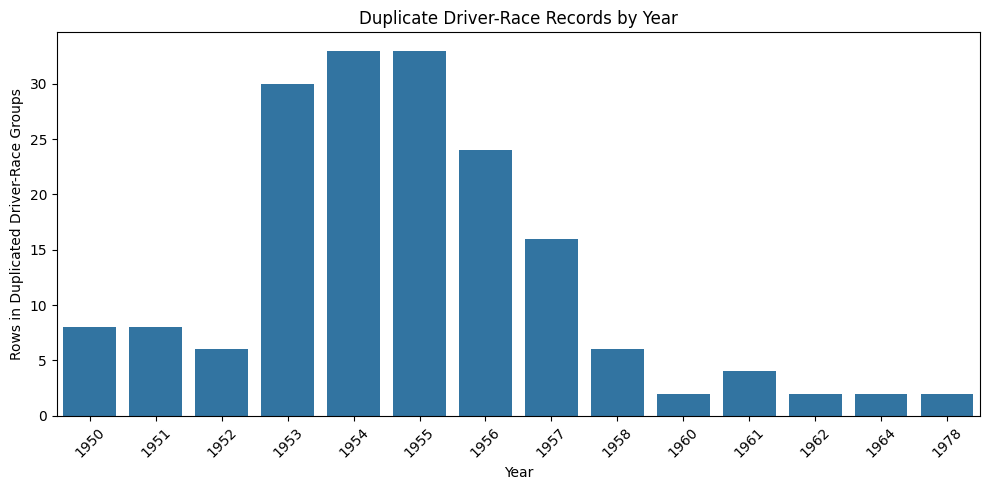

In [46]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=duplicates_by_year,
    x="year",
    y="Duplicate_Rows"
)

plt.title("Duplicate Driver-Race Records by Year")
plt.xlabel("Year")
plt.ylabel("Rows in Duplicated Driver-Race Groups")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Shared-Drive Resolution

The required modeling grain is exactly one observation for each `(raceId, driverId)`
combination. However, 85 historical driver-race combinations contain multiple result
records due primarily to shared drives in early Formula 1.

For each duplicated `(raceId, driverId)` group, the record with the smallest
`positionOrder` is retained. Since a smaller `positionOrder` represents a better
finishing classification, this preserves the driver's best recorded race outcome and
ensures that a podium result is retained if any of the driver's shared-drive records
finished in the top three.

If multiple records have the same `positionOrder`, the smallest `resultId` is used as
a deterministic tie-breaker.

This process removes 91 additional rows while preserving one complete result record
for each driver-race combination. `positionOrder` is retained because it is required
later to construct the podium target (`positionOrder <= 3`). Although it is needed for
target construction, it will not be used as a predictive feature because it is only
known after the race.

After resolution, `(raceId, driverId)` uniqueness is checked again to confirm the
required one-row-per-driver-per-race grain.

In [104]:
duplicate_group_sizes = (
    clean_data["results"]
    .groupby(["raceId", "driverId"])
    .size()
    .reset_index(name="Rows_Per_Driver_Race")
)

duplicate_group_sizes = duplicate_group_sizes[
    duplicate_group_sizes["Rows_Per_Driver_Race"] > 1
]

print("Number of duplicated driver-race groups:", len(duplicate_group_sizes))
print(
    "Extra rows that must be removed:",
    (duplicate_group_sizes["Rows_Per_Driver_Race"] - 1).sum()
)

display(
    duplicate_group_sizes["Rows_Per_Driver_Race"]
    .value_counts()
    .sort_index()
    .rename_axis("Rows_Per_Driver_Race")
    .reset_index(name="Number_of_Groups")
)

Number of duplicated driver-race groups: 85
Extra rows that must be removed: 91


,Rows_Per_Driver_Race,Number_of_Groups
0,2,79
1,3,6


In [74]:
results_model = (
    clean_data["results"]
    .sort_values(
        ["raceId", "driverId", "positionOrder", "resultId"],
        ascending=[True, True, True, True]
    )
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "Rows before duplicate resolution:",
    len(clean_data["results"])
)

print(
    "Rows after duplicate resolution:",
    len(results_model)
)

print(
    "Rows removed:",
    len(clean_data["results"]) - len(results_model)
)

Rows before duplicate resolution: 26759
Rows after duplicate resolution: 26668
Rows removed: 91


In [75]:
remaining_driver_race_duplicates = (
    results_model
    .duplicated(
        subset=["raceId", "driverId"]
    )
    .sum()
)

print(
    "Remaining duplicate (raceId, driverId) pairs:",
    remaining_driver_race_duplicates
)

assert remaining_driver_race_duplicates == 0

print("Required one-row-per-driver-per-race grain confirmed.")

Remaining duplicate (raceId, driverId) pairs: 0
Required one-row-per-driver-per-race grain confirmed.


## 1.9 Post-Cleaning Exploratory Data Analysis

After cleaning, the data is explored again to evaluate the impact of the transformations.

The post-cleaning EDA examines:
- missingness after converting sentinel values to proper `NaN`;
- changes in Pandas-recognized missingness before and after sentinel cleaning;
- structural patterns in missing data;
- the success of date and duration conversions;
- the distributions of newly converted duration variables;
- the effect of resolving duplicate driver-race records;
- and the final data-quality status.

These checks verify that the cleaning operations produced their intended effects and
help identify whether any additional cleaning is required before constructing the
modeling table.

### 1.9.1 Missingness After Cleaning

Missingness is recalculated after sentinel replacement using Pandas-native missing-value
detection.

At this stage, missing values are not expected to disappear because sentinel cleaning
standardized their representation rather than imputing or deleting them. The purpose of
this analysis is therefore to verify that missing information is now consistently
represented as proper `NaN` values and can be handled correctly in later processing.

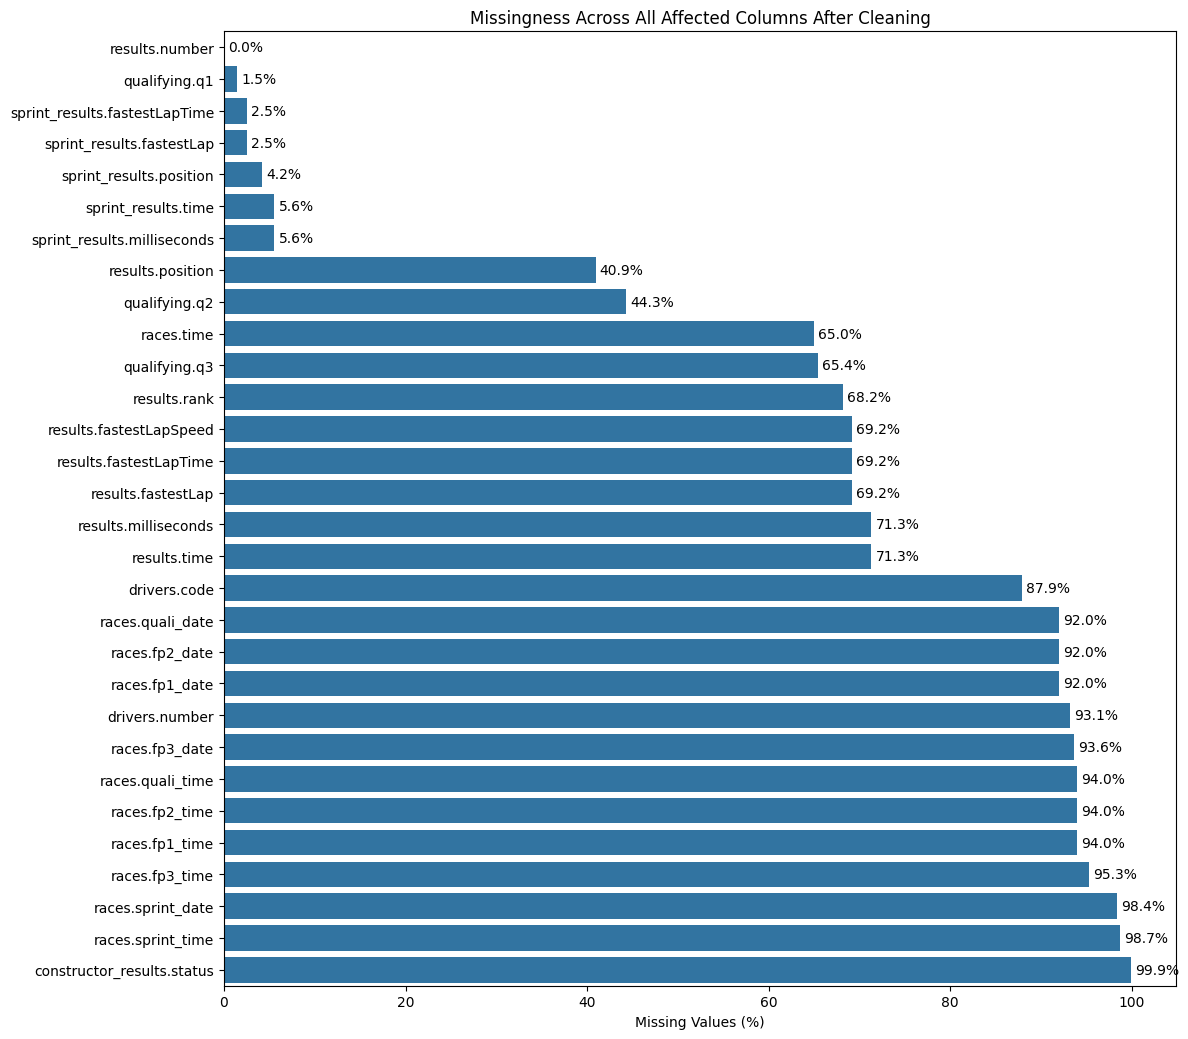

In [47]:
missing_after = []

for table_name, df in clean_data.items():

    for column in df.columns:

        # Exclude newly derived duration columns so the comparison
        # remains focused on the original dataset variables.
        if column.endswith("_seconds"):
            continue

        missing_count = df[column].isnull().sum()

        if missing_count > 0:
            missing_after.append({
                "Feature": f"{table_name}.{column}",
                "Missing_Count": missing_count,
                "Missing_Percentage": missing_count / len(df) * 100
            })

missing_after = pd.DataFrame(missing_after)

missing_after_plot = (
    missing_after
    .sort_values("Missing_Percentage", ascending=True)
    .copy()
)

plt.figure(
    figsize=(12, max(7, len(missing_after_plot) * 0.35))
)

ax = sns.barplot(
    data=missing_after_plot,
    x="Missing_Percentage",
    y="Feature"
)

plt.title("Missingness Across All Affected Columns After Cleaning")
plt.xlabel("Missing Values (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

#### Observation

Missingness remains highly uneven across the dataset after cleaning. Some variables have
very high levels of missingness, while others are only slightly affected.

This is expected because replacing `\N` with `NaN` standardizes missing-value
representation but does not remove or impute missing information. The variation also
shows why a single global missing-value rule would be inappropriate: missingness must
later be handled according to the meaning and modeling role of individual features.

### 1.9.2 Effect of Sentinel Cleaning on Recognized Missingness

Before cleaning, the literal string `\N` was stored as ordinary text and was therefore
not recognized by Pandas as a missing value. Standard missing-value detection consequently
underestimated missingness in columns containing these sentinels.

The following visualization compares the percentage of missing values recognized by
Pandas before and after sentinel replacement. An increase after cleaning does not mean
that new information was lost; it means that previously hidden `\N` values are now
correctly represented and detected as `NaN`.

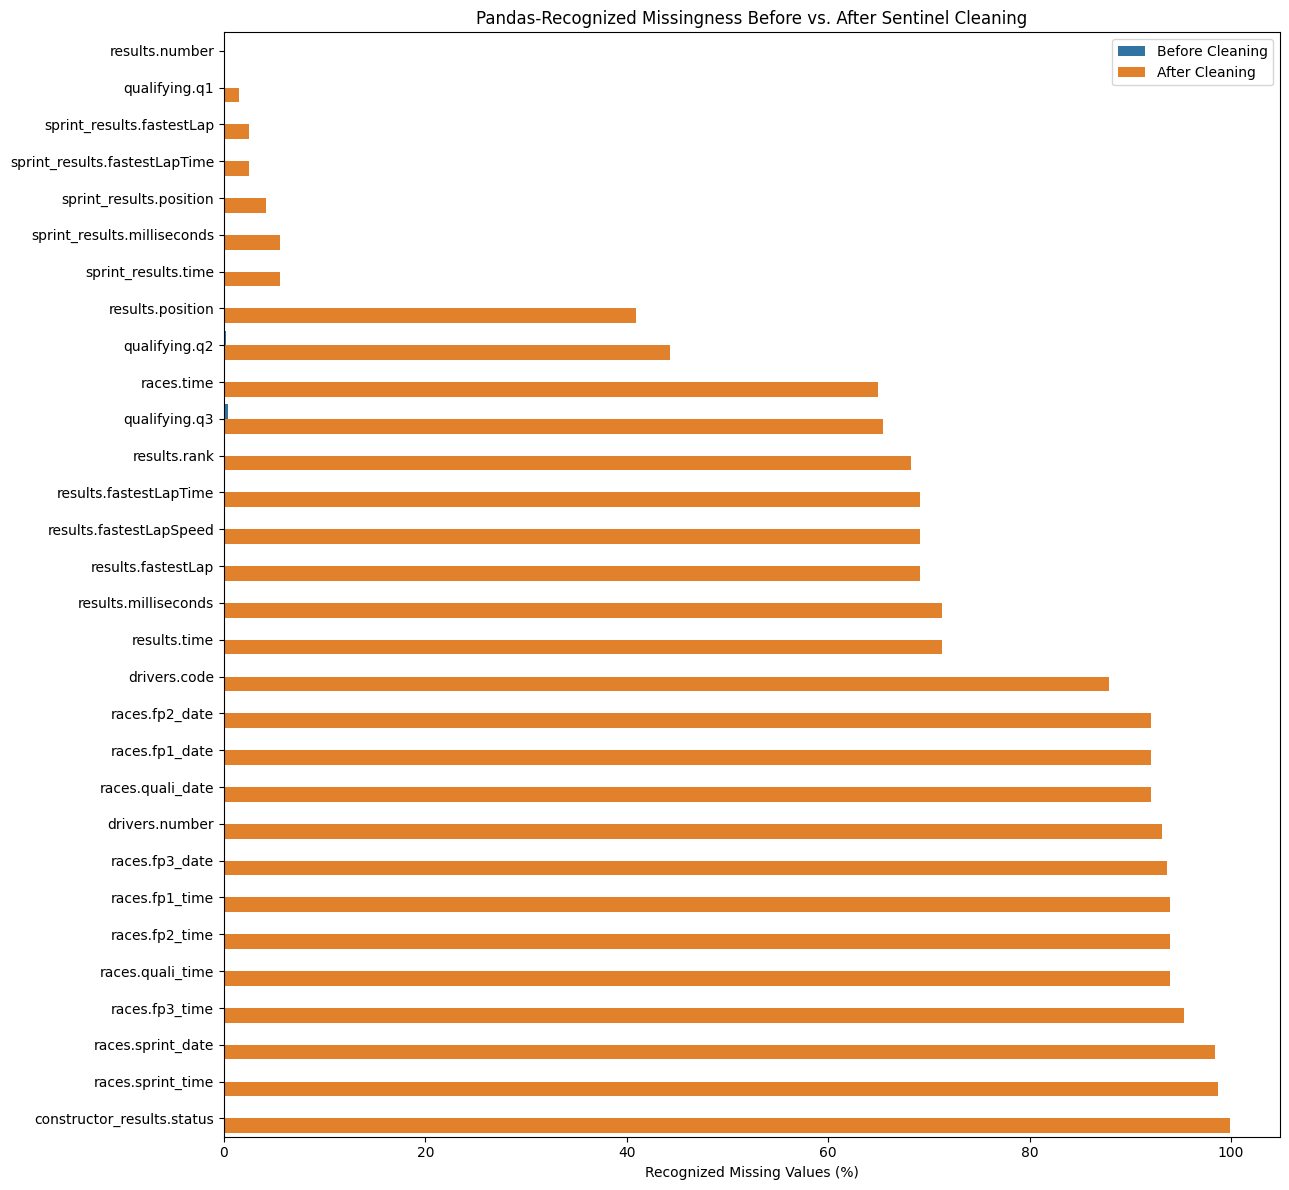

In [49]:
recognized_before = []
recognized_after = []

# Pandas-recognized missingness in the raw data
for table_name, df in raw_data.items():

    for column in df.columns:

        recognized_before.append({
            "Feature": f"{table_name}.{column}",
            "Before Cleaning": df[column].isnull().sum() / len(df) * 100
        })


# Pandas-recognized missingness after cleaning
for table_name, df in clean_data.items():

    for column in df.columns:

        if column.endswith("_seconds"):
            continue

        recognized_after.append({
            "Feature": f"{table_name}.{column}",
            "After Cleaning": df[column].isnull().sum() / len(df) * 100
        })


recognized_before = pd.DataFrame(recognized_before)
recognized_after = pd.DataFrame(recognized_after)

recognized_comparison = recognized_before.merge(
    recognized_after,
    on="Feature",
    how="outer"
).fillna(0)

# Only display variables with missingness before or after cleaning
recognized_comparison = recognized_comparison[
    (recognized_comparison["Before Cleaning"] > 0) |
    (recognized_comparison["After Cleaning"] > 0)
]

recognized_comparison = recognized_comparison.sort_values(
    "After Cleaning",
    ascending=True
)

recognized_long = recognized_comparison.melt(
    id_vars="Feature",
    var_name="Stage",
    value_name="Missing_Percentage"
)

plt.figure(
    figsize=(13, max(7, len(recognized_comparison) * 0.4))
)

sns.barplot(
    data=recognized_long,
    x="Missing_Percentage",
    y="Feature",
    hue="Stage"
)

plt.title("Pandas-Recognized Missingness Before vs. After Sentinel Cleaning")
plt.xlabel("Recognized Missing Values (%)")
plt.ylabel("")
plt.legend(title="")

plt.tight_layout()
plt.show()

#### Observation

The comparison shows a substantial increase in Pandas-recognized missingness after
sentinel cleaning for many affected variables. Before cleaning, most `\N` values were
treated as ordinary strings and therefore did not appear in standard null counts.

After converting `\N` to `NaN`, these existing missing values become correctly
recognized. The increase therefore reflects improved missing-value representation,
not the creation of new missing data.

### 1.9.3 Missingness Patterns

Missing-value percentages show how much information is absent, but they do not show
whether missing values occur together within the same observations.

Missingness matrices are therefore examined for `races`, `qualifying`, and `results`.
These tables contain several related variables with substantial missingness, making
row-level patterns particularly useful to inspect. Tables with no missingness or
missingness concentrated in only one or two variables are already sufficiently
described by the complete missingness summary.

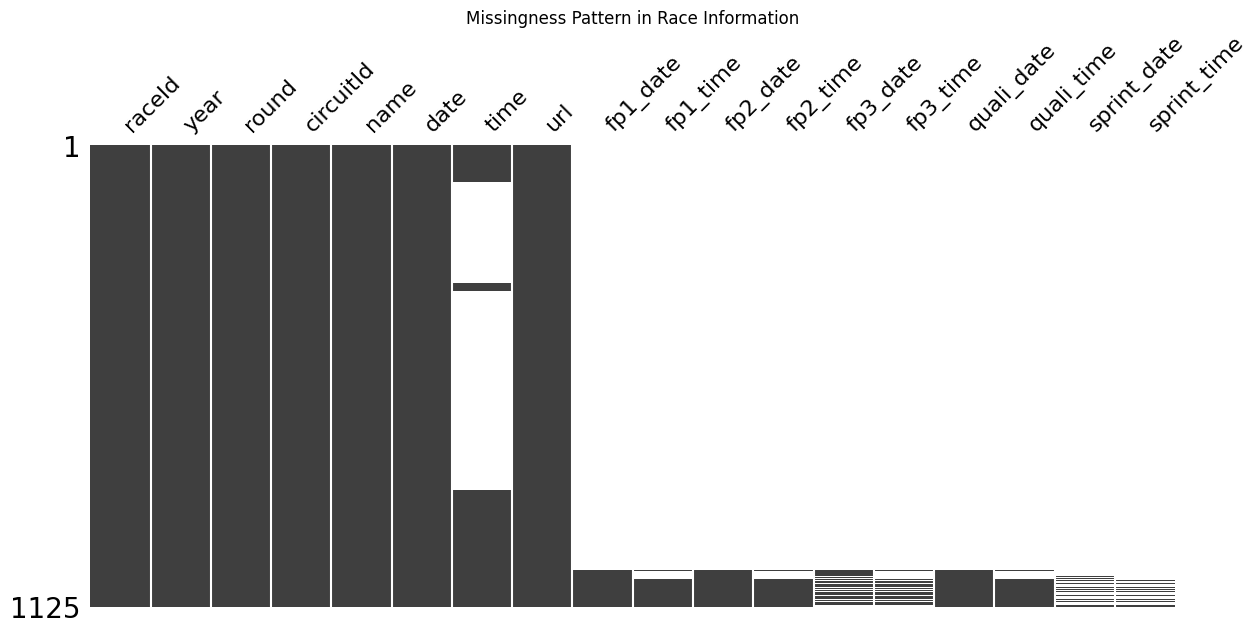

In [54]:
msno.matrix(
    clean_data["races"],
    figsize=(14, 6),
    sparkline=False
)

plt.title("Missingness Pattern in Race Information")
plt.show()

#### Race-Information Observation

The `races` table shows a clear structural pattern in missingness. Core race information,
including race identifiers, year, round, circuit, name, and date, is consistently available,
while detailed session date and time fields are much less complete.

The missing values are concentrated in specific session-related fields rather than being
uniformly distributed across all variables. This suggests that the missingness is
systematic and should be investigated according to the meaning and availability of each
field rather than handled using a single global missing-value rule.

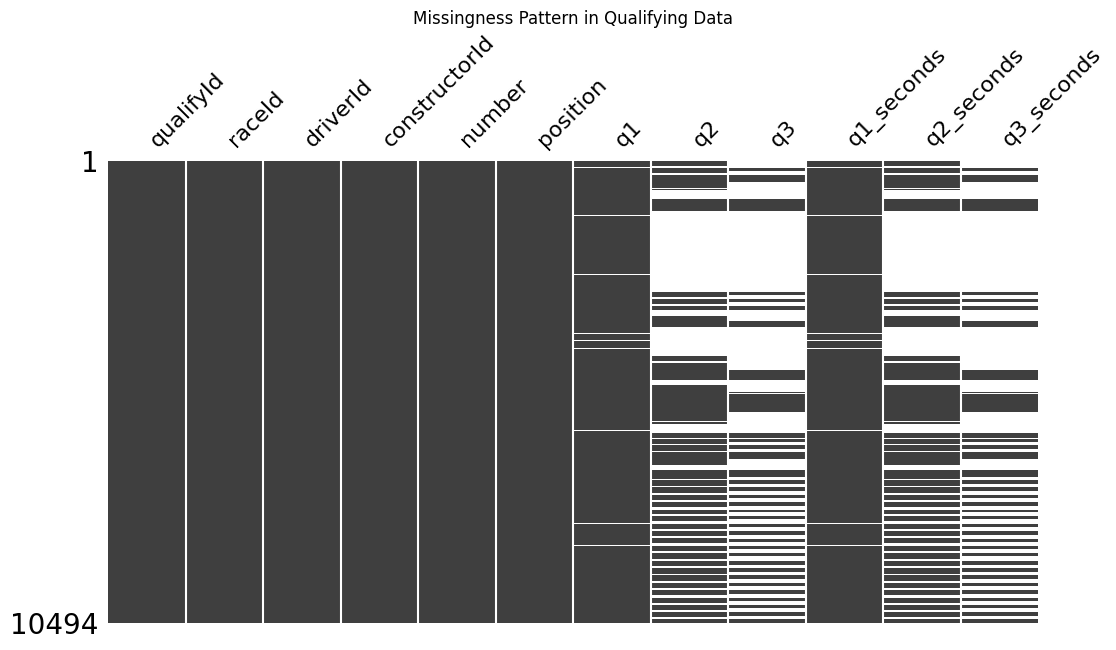

In [51]:
msno.matrix(
    clean_data["qualifying"],
    figsize=(12, 6),
    sparkline=False
)

plt.title("Missingness Pattern in Qualifying Data")
plt.show()

#### Qualifying Observation

The `qualifying` table shows progressively lower coverage across the qualifying-session
time fields, with Q1 being substantially more complete than Q2 and Q3. Identifier and
qualifying-position fields remain complete.

The missingness patterns of `q1`, `q2`, and `q3` are also mirrored by their corresponding
`_seconds` variables, providing visual evidence that duration conversion preserved the
existing missing-value structure rather than introducing widespread additional
missingness.

These patterns support handling qualifying missingness according to its meaning and
historical availability rather than applying a single global deletion or imputation rule.

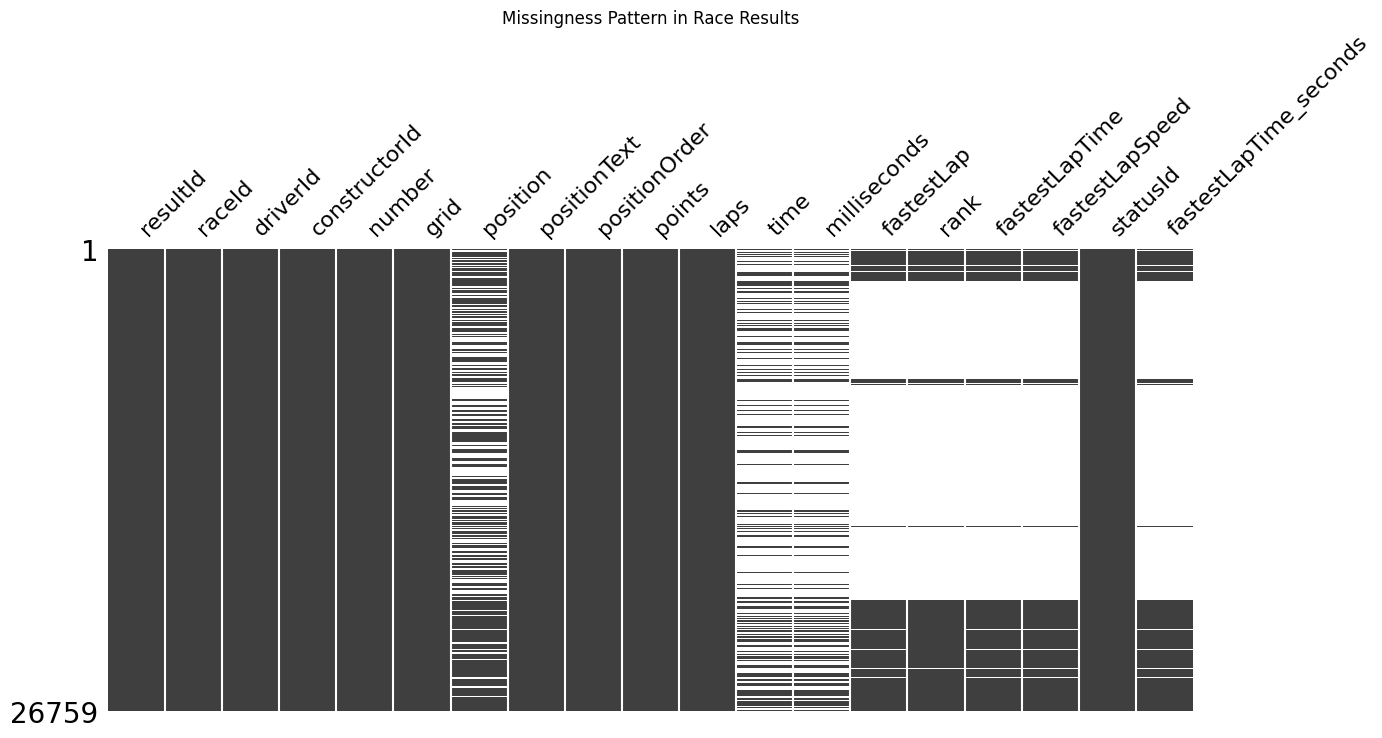

In [56]:
msno.matrix(
    clean_data["results"],
    figsize=(14, 6),
    sparkline=False
)

plt.title("Missingness Pattern in Race Results")
plt.show()

#### Race-Results Observation

The `results` table shows complete coverage for the main identifiers and several core
race variables, including `positionOrder`, while timing and fastest-lap measurements
have substantially lower coverage.

The completeness of `positionOrder` is important because it will later be used to
construct the podium target. The converted `fastestLapTime_seconds` variable also
follows the missingness pattern of its original source field, supporting the consistency
of the duration conversion.

The structured missingness in the remaining result fields is retained at this stage
rather than being removed through global row deletion or imputation.

### 1.9.4 Semantic Conversion Validation

Successful datatype conversion requires more than checking the resulting datatype.
Because invalid values can be silently converted to missing values during parsing,
conversion success is explicitly audited.

For each converted date or duration variable, a parse failure is defined as an
observation where the cleaned source value is present but the converted value is
missing. This distinguishes genuine missing data from missing values introduced by a
failed conversion.

In [57]:
semantic_audit = []

# Date conversions

date_columns = {
    "races": [
        "date",
        "fp1_date",
        "fp2_date",
        "fp3_date",
        "quali_date",
        "sprint_date"
    ],
    "drivers": [
        "dob"
    ]
}

for table_name, columns in date_columns.items():

    for column in columns:

        # Compare against the original raw value after excluding \N
        source = raw_data[table_name][column].replace(
            r"^\s*\\N\s*$",
            np.nan,
            regex=True
        )

        converted = clean_data[table_name][column]

        source_present = source.notna()
        parse_failures = (
            source_present & converted.isna()
        ).sum()

        semantic_audit.append({
            "Variable": f"{table_name}.{column}",
            "Semantic_Type": "Date",
            "Source_Values": source_present.sum(),
            "Parse_Failures": parse_failures
        })


# Duration conversions

duration_columns_audit = {
    "results": ["fastestLapTime"],
    "qualifying": ["q1", "q2", "q3"],
    "lap_times": ["time"],
    "pit_stops": ["duration"],
    "sprint_results": ["fastestLapTime"]
}

for table_name, columns in duration_columns_audit.items():

    for column in columns:

        source = clean_data[table_name][column]
        converted = clean_data[table_name][f"{column}_seconds"]

        source_present = source.notna()

        parse_failures = (
            source_present & converted.isna()
        ).sum()

        semantic_audit.append({
            "Variable": f"{table_name}.{column}",
            "Semantic_Type": "Duration",
            "Source_Values": source_present.sum(),
            "Parse_Failures": parse_failures
        })


semantic_audit = pd.DataFrame(semantic_audit)

semantic_audit["Successful_Conversions"] = (
    semantic_audit["Source_Values"]
    - semantic_audit["Parse_Failures"]
)

semantic_audit["Success_Rate"] = np.where(
    semantic_audit["Source_Values"] > 0,
    semantic_audit["Successful_Conversions"]
    / semantic_audit["Source_Values"] * 100,
    np.nan
)

display(semantic_audit)

,Variable,Semantic_Type,Source_Values,Parse_Failures,Successful_Conversions,Success_Rate
0,races.date,Date,1125,0,1125,100.0
1,races.fp1_date,Date,90,0,90,100.0
2,races.fp2_date,Date,90,0,90,100.0
3,races.fp3_date,Date,72,0,72,100.0
4,races.quali_date,Date,90,0,90,100.0
5,races.sprint_date,Date,18,0,18,100.0
6,drivers.dob,Date,861,0,861,100.0
7,results.fastestLapTime,Duration,8252,0,8252,100.0
8,qualifying.q1,Duration,10338,0,10338,100.0
9,qualifying.q2,Duration,5847,0,5847,100.0


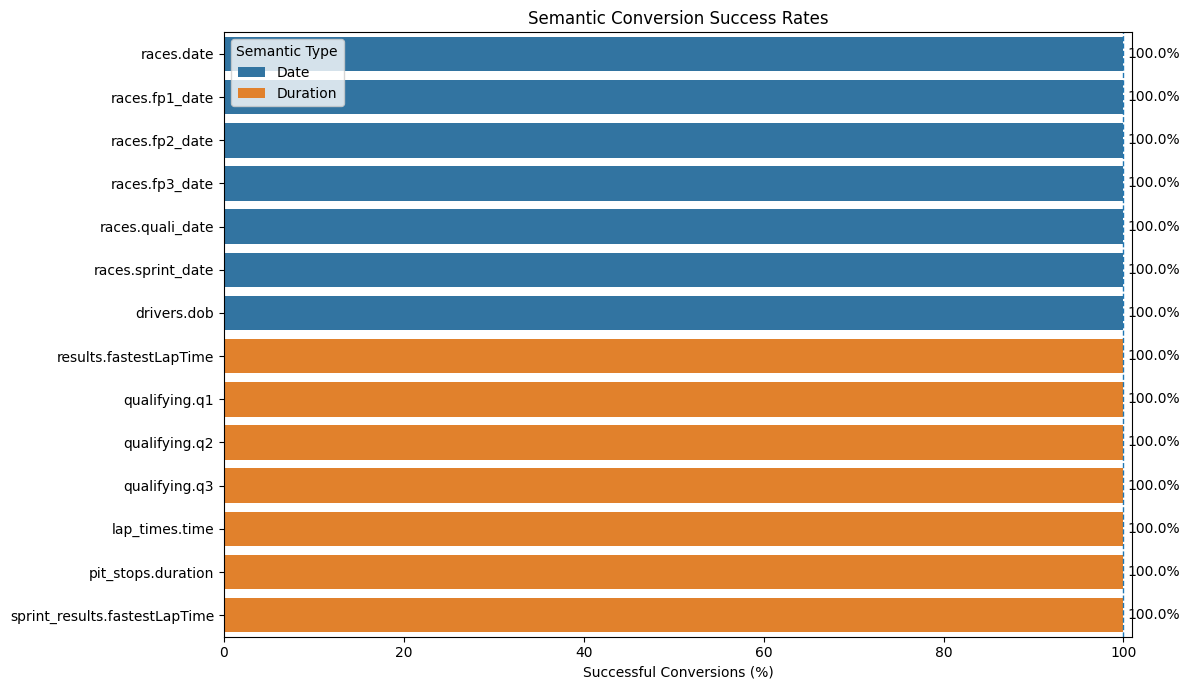

In [58]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=semantic_audit,
    x="Success_Rate",
    y="Variable",
    hue="Semantic_Type"
)

plt.axvline(
    100,
    linestyle="--",
    linewidth=1
)

plt.xlim(0, 101)

plt.title("Semantic Conversion Success Rates")
plt.xlabel("Successful Conversions (%)")
plt.ylabel("")
plt.legend(title="Semantic Type")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [59]:
total_parse_failures = semantic_audit["Parse_Failures"].sum()

print(
    "Total semantic conversion failures:",
    total_parse_failures
)

Total semantic conversion failures: 0


### 1.9.3 Relational-Integrity Validation

Primary-key and foreign-key checks are summarized after cleaning to verify that the
relational structure of the dataset remains valid.

A successful primary-key check means that the tested keys are unique and non-null,
while a successful foreign-key check means that all tested references match existing
records in their corresponding parent tables.

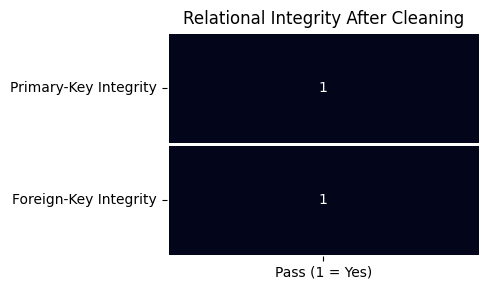

In [71]:
integrity_summary = pd.DataFrame({
    "Check": [
        "Primary-Key Integrity",
        "Foreign-Key Integrity"
    ],
    "Passed": [
        pk_results["Valid"].all(),
        fk_results["Valid"].all()
    ]
})

integrity_plot = (
    integrity_summary
    .set_index("Check")[["Passed"]]
    .astype(int)
)

plt.figure(figsize=(5, 3))

sns.heatmap(
    integrity_plot,
    annot=True,
    fmt="d",
    cbar=False,
    linewidths=1,
    xticklabels=["Pass (1 = Yes)"]
)

plt.title("Relational Integrity After Cleaning")
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

#### Observation

All tested primary-key and foreign-key integrity checks pass after cleaning. The tested
primary keys remain unique and non-null, and all tested foreign-key values reconcile
with their corresponding parent tables.

This confirms that the cleaning process preserved the tested relational structure of
the dataset.

### 1.9.4 Driver-Race Duplicate Resolution

The effect of the shared-drive resolution is evaluated by comparing the number of
excess `(raceId, driverId)` rows before and after applying the documented resolution
rule.

The resulting driver-race base must contain exactly one observation for each
`(raceId, driverId)` combination.

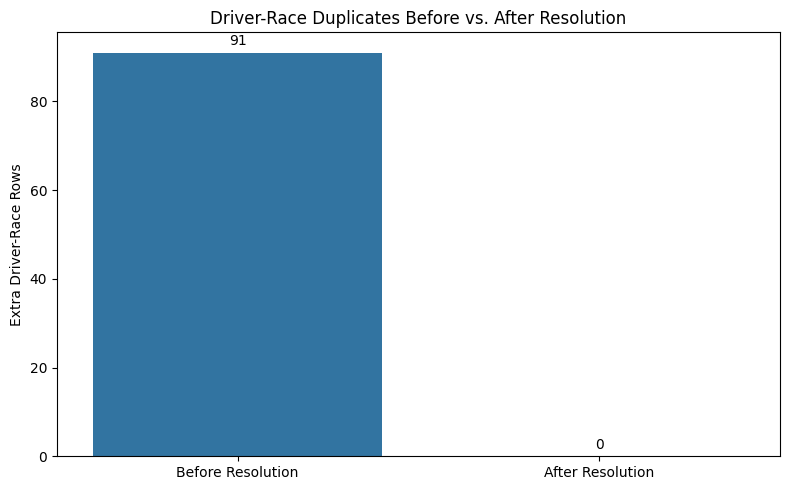

In [76]:
grain_comparison = pd.DataFrame({
    "Stage": [
        "Before Resolution",
        "After Resolution"
    ],
    "Extra_Driver_Race_Rows": [
        clean_data["results"]
        .duplicated(subset=["raceId", "driverId"])
        .sum(),

        results_model
        .duplicated(subset=["raceId", "driverId"])
        .sum()
    ]
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=grain_comparison,
    x="Stage",
    y="Extra_Driver_Race_Rows"
)

plt.title("Driver-Race Duplicates Before vs. After Resolution")
plt.xlabel("")
plt.ylabel("Extra Driver-Race Rows")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

#### Observation

Before resolution, 91 excess rows violated the required one-row-per-driver-per-race
grain. After applying the shared-drive resolution rule, no duplicate
`(raceId, driverId)` combinations remain.

This confirms that `results_model` satisfies the required unique driver-race grain.